<a href="https://colab.research.google.com/github/Vader7-166/Mapping_DulieuHQ/blob/main/PhoBert%20mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pip install -q transformers datasets accelerate scikit-learn pandas "numpy<2.3.0" matplotlib seaborn

In [ ]:

import pandas as pd
import numpy as np
import re
import pickle
import torch
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import warnings
from IPython.display import display

"""Tắt cảnh báo rác trên màn hình"""
warnings.filterwarnings('ignore')

In [ ]:

DATA_PATH = '/content/drive/MyDrive/CleanData/datasets/HQ-2025.csv'
MODEL_SAVE_PATH = '/content/drive/MyDrive/CleanData/working/model'
CHECKPOINT_PATH = '/content/drive/MyDrive/CleanData/working/model/checkpoints'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("Đang đọc dữ liệu Input...")
try:
    df_train = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip', low_memory=False, dtype=str)
except:
    df_train = pd.read_csv(DATA_PATH, encoding='latin1', on_bad_lines='skip', low_memory=False, dtype=str)

"""Loại bỏ các dòng không có tên hàng"""
df_train = df_train.dropna(subset=['Tên hàng'])
print(f"Số dòng dữ liệu ban đầu: {len(df_train)}")

"""Hiển thị dữ liệu trực quan"""
display(df_train.head())

Đang đọc dữ liệu Input...
Số dòng dữ liệu ban đầu: 9808


,Ngày,Mã HS,Công ty NK,Tên hàng,DVT,Lượng,Giá trị,Đơn giá,Unnamed: 8,Hãng,...,Quốc gia,Châu lục,MDSD,Công ty XK,Incoterms,Method_of_Payment,Công suất.1,Loại 1,Loại 2,Năm
0,Tháng 1,94056190,CôNG TY TNHH OHSUNG VINA THáI BìNH,#&Biển hiệu công ty được chiếu sáng bằng đèn l...,Pieces,1,2828,"2828,01",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH XAY DUNG MIRAE,DAP,KC,NaN,NaN,NaN,NaN
1,Tháng 1,94054990,CôNG TY TNHH DONGKWANG,"#&Bóng đèn 600x600 48W,hàng mới 100%",Pieces,10,209,"20,9",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH DN 365,DAP,KC,NaN,NaN,NaN,NaN
2,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led 60cm, là loại bóng đèn tuýp led...",Pieces,129,552,"4,28",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
3,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led Rạng Đông 20W, là loại bóng đèn...",Pieces,527,743,"1,41",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
4,Tháng 1,85392190,CôNG TY TNHH ĐIệN Tử SNC VIệT NAM,".#&Đèn halogen hiệu chỉnh thiết bị D204C, điện...",Pieces,2,231,"115,68",NaN,NaN,...,China (CN),Asia,NaN,HONGKONG SNC LIGHTING CO LTD,CIF,OA,NaN,NaN,NaN,NaN


Tổng số nhãn phân loại: 41
--- KẾT QUẢ CHIA TẬP DATA ---
Train: 7836 mẫu | Val: 979 mẫu | Test: 980 mẫu


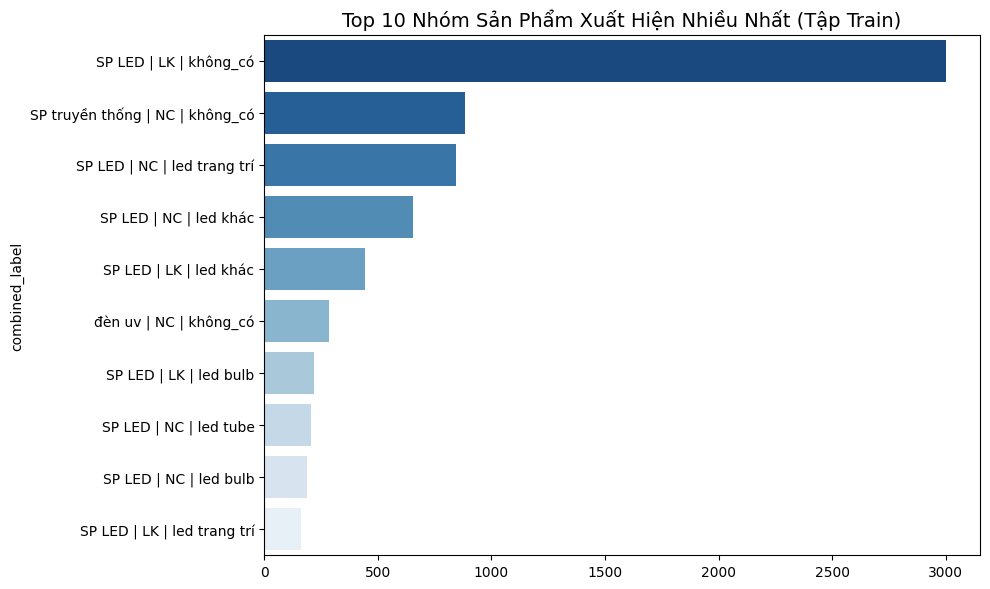

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()

df_train.fillna('', inplace=True)
df_train['text'] = "Hãng: " + df_train['Hãng'].astype(str) + " - Công suất: " + df_train['Công suất'].astype(str) + " - Sản phẩm: " + df_train['Tên hàng'].astype(str)
df_train['text'] = df_train['text'].apply(clean_text)
df_train = df_train[df_train['text'] != '']
cols_to_predict = ['Dòng SP', 'Loại', 'Lớp 1']
for col in cols_to_predict:
    df_train[col] = df_train[col].replace('', 'không_có')

df_train['combined_label'] = df_train['Dòng SP'] + " | " + df_train['Loại'] + " | " + df_train['Lớp 1']

"""Lọc nhãn rác (xuất hiện dưới 5 lần)"""
label_counts = df_train['combined_label'].value_counts()
valid_labels = label_counts[label_counts >= 5].index
df_train = df_train[df_train['combined_label'].isin(valid_labels)]

"""Mã hóa nhãn"""
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['combined_label'])
num_labels = len(label_encoder.classes_)
print(f"Tổng số nhãn phân loại: {num_labels}")

"""Chia tập dữ liệu chuẩn 80/10/10"""
train_df, temp_df = train_test_split(df_train[['text', 'label', 'Tên hàng', 'combined_label']], test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
test_df = test_df.copy()

print("--- KẾT QUẢ CHIA TẬP DATA ---")
print(f"Train: {len(train_df)} mẫu | Val: {len(val_df)} mẫu | Test: {len(test_df)} mẫu")

"""Vẽ biểu đồ phân bổ dữ liệu"""
plt.figure(figsize=(10, 6))
top_labels = train_df['combined_label'].value_counts().head(10)
sns.barplot(x=top_labels.values, y=top_labels.index, palette='Blues_r')
plt.title('Top 10 Nhóm Sản Phẩm Xuất Hiện Nhiều Nhất (Tập Train)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir=CHECKPOINT_PATH,
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    report_to="none",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---")
trainer.train()

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1470, training_loss=1.0491189762037627, metrics={'train_runtime': 294.2076, 'train_samples_per_second': 79.903, 'train_steps_per_second': 4.996, 'total_flos': 1546845134183424.0, 'train_loss': 1.0491189762037627, 'epoch': 3.0})


--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---


ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: 89.80%



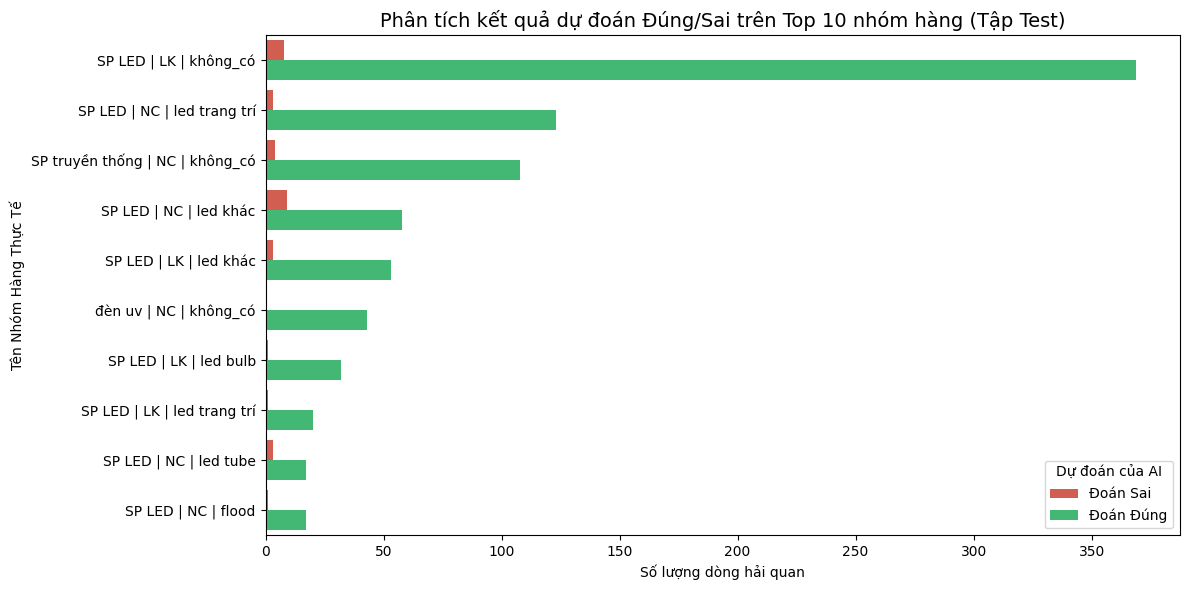

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print("\n--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---")

test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

test_acc = accuracy_score(test_labels, test_preds)
print(f"==========================================================")
print(f"ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: {test_acc * 100:.2f}%")
print(f"==========================================================\n")

"""Giải mã số thành nhãn chữ"""
test_df['predicted_label'] = label_encoder.inverse_transform(test_preds)
test_df['is_correct'] = test_df['combined_label'] == test_df['predicted_label']
top_test_labels = test_df['combined_label'].value_counts().head(10).index
test_df_top = test_df[test_df['combined_label'].isin(top_test_labels)].copy()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=test_df_top,
    y='combined_label',
    hue='is_correct',
    order=top_test_labels,
    palette={True: '#2ecc71', False: '#e74c3c'}
)
plt.title('Phân tích kết quả dự đoán Đúng/Sai trên Top 10 nhóm hàng (Tập Test)', fontsize=14)
plt.xlabel('Số lượng dòng hải quan')
plt.ylabel('Tên Nhóm Hàng Thực Tế')
plt.legend(title='Dự đoán của AI', labels=['Đoán Sai', 'Đoán Đúng'])
plt.tight_layout()
plt.show()


THU_MUC_LUU_TRUC_TIEP = '/content/drive/MyDrive/CleanData/working/'
trainer.save_model(THU_MUC_LUU_TRUC_TIEP)
with open(f"{THU_MUC_LUU_TRUC_TIEP}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


In [ ]:
import torch
import pandas as pd
import re
import pickle
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
LABEL_ENCODER_PATH = "/content/drive/MyDrive/CleanData/working/label_encoder.pkl"
INPUT_FILE = "/content/drive/MyDrive/CleanData/datasets/sample-data.csv"   # Đảm bảo file này có cột chứa tên hàng raw
OUTPUT_FILE = "/content/drive/MyDrive/CleanData/datasets/ket_qua_phan_loai.csv"

# ==========================================
# 2. TẢI MÔ HÌNH VÀ CÔNG CỤ
# ==========================================
print("Đang nạp mô hình AI...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/CleanData/working/') # Đã sửa đường dẫn tại đây

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

with open(LABEL_ENCODER_PATH, 'rb') as f:
    label_encoder = pickle.load(f)

# ==========================================
# 3. CÁC HÀM XỬ LÝ DỮ LIỆU CHÍNH
# ==========================================

def boc_tach_va_ghep_chuoi(raw_text):
    """
    Hàm này đọc câu raw, tìm Hãng, Công suất và ghép lại thành format chuẩn cho AI
    Ví dụ: 'bóng tuýp led rạng đông 20w' -> 'Hãng: rạng đông - Công suất: 20w - Sản phẩm: bóng tuýp led rạng đông 20w'
    """
    raw_text = str(raw_text).lower()

    # A. Tìm công suất (Tìm số đi liền với W, Watt, HP, kW, V...)
    cong_suat = ""
    match_w = re.search(r'(\d+(?:\.\d+)?)\s*(w|watt|hp|kw|v)', raw_text)
    if match_w:
        cong_suat = match_w.group(0) # Lấy luôn cả số và chữ (vd: 20w)

    # B. Tìm hãng (Dùng danh sách các hãng phổ biến trong ngành của bạn)
    # BẠN HÃY THÊM CÁC HÃNG THƯỜNG GẶP VÀO DANH SÁCH NÀY
    hang = ""
    danh_sach_hang = ['rạng đông', 'điện quang', 'panasonic', 'philips', 'lg', 'samsung', 'daikin', 'sony', 'toshiba', 'sharp', 'sino', 'cadivi']
    for h in danh_sach_hang:
        if h in raw_text:
            hang = h
            break # Nếu tìm thấy hãng rồi thì dừng

    # C. Ghép thành format chuẩn như lúc Train
    # Lưu ý: Chữ "Sản phẩm: " ta cứ truyền nguyên câu raw vào, AI sẽ tự hiểu
    formatted_text = f"Hãng: {hang} - Công suất: {cong_suat} - Sản phẩm: {raw_text}"
    return formatted_text

def clean_text(text):
    """Làm sạch ký tự đặc biệt giống hệt lúc train"""
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()

def predict_single_text(text):
    """Đưa chuỗi đã chuẩn hóa vào AI để lấy kết quả"""
    inputs = tokenizer(text, padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=-1).item()
    return label_encoder.inverse_transform([pred_id])[0]

# ==========================================
# 4. CHẠY TRÊN FILE DỮ LIỆU
# ==========================================
print(f"Đang đọc dữ liệu từ {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# BẠN THAY 'Ten_Hang_Raw' BẰNG TÊN CỘT CHỨA TEXT TRONG FILE CỦA BẠN NHÉ
ten_cot_raw = 'Tên hàng'

# Bước 1: Bóc tách và ghép chuỗi giả lập cấu trúc Train
print("Đang tiền xử lý văn bản tự do thành cấu trúc AI nhận diện...")
df['input_for_ai'] = df[ten_cot_raw].apply(boc_tach_va_ghep_chuoi)

# Bước 2: Làm sạch ký tự
df['input_for_ai'] = df['input_for_ai'].apply(clean_text)

# Bước 3: Đưa vào AI dự đoán
print("AI đang tiến hành phân loại...")
df['Ket_Qua_Gop'] = df['input_for_ai'].apply(predict_single_text)

# Bước 4: Điền kết quả
print("Đang điền kết quả vào các cột Dòng SP, Loại, Lớp 1 có sẵn...")
df[['Dòng SP', 'Loại', 'Lớp 1']] = df['Ket_Qua_Gop'].str.split(' \| ', n=2, expand=True)

# Dọn dẹp cột nháp
df = df.drop(columns=['input_for_ai', 'Ket_Qua_Gop'])

# Xuất kết quả
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f"Hoàn tất! File kết quả đã được cập nhật: {OUTPUT_FILE}")

Đang nạp mô hình AI...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Đang đọc dữ liệu từ /content/datasets/sample-data.csv...
Đang tiền xử lý văn bản tự do thành cấu trúc AI nhận diện...
AI đang tiến hành phân loại...
Đang điền kết quả vào các cột Dòng SP, Loại, Lớp 1 có sẵn...
Hoàn tất! File kết quả đã được cập nhật: /content/datasets/ket_qua_phan_loai.csv
